In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

## Interpolazione di curve nel piano

Una curva parametrica nel piano cartesiano è l'insieme di punti di coordinate
$$(x(t),y(t)), \ \ t\in[a,b] $$

dove $t$ è il parametro della curva.

Esempi:
La circonferenza di raggio $R^2$ è descritta dalle equazioni
$$\begin{cases} x(t) = R\cos(t)\\ y(t) = R\sin(t)\end{cases} $$
con $t\in [0,2\pi]$.

Un'altro esempio di curva nel piano è il seguente
$$\begin{cases} x(t) &=& 16\sin^3(x) \\
 y(t) &=& 13\cos(t)-5\cos(2t)-2\cos(3t)-\cos(4t)\end{cases} $$

con $t\in [0,2\pi]$.


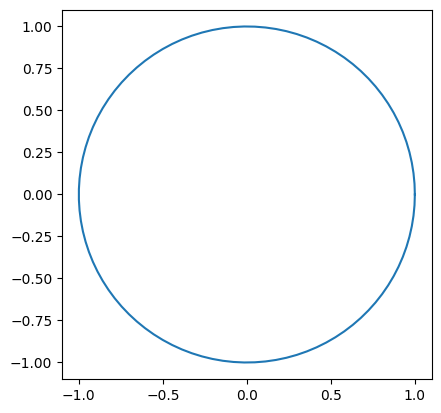

In [6]:
# Crea il grafico della prima curva
n = 100     # Punti da interpolare
a = 0
b = 2*np.pi

# Prendo cento punti equispaziati in [a,b]
t = np.linspace(a,b,num=n)

# Definisco il raggio
R = 1

# Funzione della circonferenza
circonferenza = lambda t: (R*np.cos(t),R*np.sin(t))
# Calcolo dei punti della criconferenza con t vettore
(xt,yt) = circonferenza(t)

# Plot della circonferenza
fig,ax = plt.subplots()
plt.plot(xt,yt)
ax.set_aspect('equal', 'box')

plt.show()

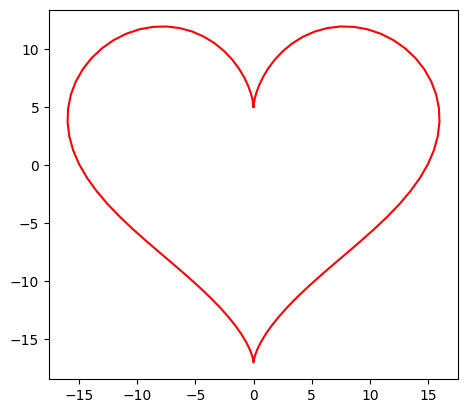

In [7]:
# Crea il grafico della seconda curva
n = 100
a = 0
b = 2*np.pi

# Prendo cento punti equispaziati in [a,b]
t = np.linspace(a,b,num=n)

# Definisco la funzione della seconda curva
curva2 = lambda t: (16*np.sin(t)**3,13*np.cos(t)-5*np.cos(2*t)-2*np.cos(3*t)-np.cos(4*t) )
# Calcolo dei punti della curva con t vettore
(xt,yt) = curva2(t)

# Plot della curva
fig,ax = plt.subplots()
plt.plot(xt,yt,'-r')
ax.set_aspect('equal', 'box')

plt.show()

Interpolare una curva significa che sono disponibili i punti
$$(x(t_i),y(t_i)),\quad i = 0,...,m $$
e a partire da questi si vogliono costruire due funzioni $s_x(t),s_y(t)$ tali che
$$\begin{array}{lcl}s_x(t_i) &=& x(t_i)\\ s_y(t_i) &=& y(t_i) \end{array} $$
per $i=0,...,m$.

Le due funzioni $s_x,s_y$ si possono definire indipendentemente l'una dall'altra mediante una delle tecniche di interpolazione (polinomio di interpolazione, spline) che abbiamo studiato finora.

## Esempi

Interpoliamo le due curve degli esempi precedenti con il polinomio di interpolazione, con le spline lineari e con le spline cubiche.

In [8]:
def polinomio_interpol(x,y,xx):
  p = np.polyfit(x,y,x.size-1) #coefficienti del polinomio
  return np.polyval(p,xx)

def piecewise_linear(x,y,xx):
  n = x.size
  yy = np.zeros(xx.shape)
  for i in range(n-1):
    ind = np.logical_and(xx>=x[i],xx<=x[i+1])
    yy[ind] = y[i] + ((y[i+1]-y[i])/(x[i+1]-x[i]))*(xx[ind]-x[i])
  return yy

def interp_spline3(x,y,xx):
  # Effettua una scelta particolare della funzione 
  #   di interpolazione che la rende unica
  cs = CubicSpline(x,y)
  return cs(xx)



def crea_grafici_curve(f,a,b,n,f_list):
  """
  funzione per creare i grafici della curva interpolata e delle curve ottenute interpolando
  in n punti equispaziati con le funzioni contenute
  nella lista f_list
  """
  fig,ax = plt.subplots()
  t = np.linspace(a,b,n) #nodi equispaziati
  (x,y) = f(t)
  plt.scatter(x,y)

  #Creazione dei grafici
  tt = np.linspace(a,b,num=200)
  (xx,yy) = f(tt)
  plt.plot(xx,yy,'--k',linewidth=2)
  for i in range(len(f_list)):
    xx = f_list[i](t,x,tt)
    yy = f_list[i](t,y,tt)
    plt.plot(xx,yy)

  ax.set_aspect("equal")
  plt.show()
  return None

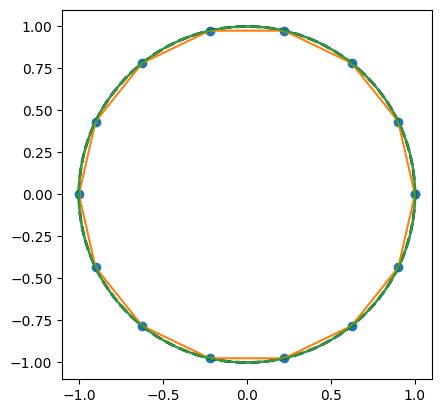

In [9]:
n = 15
interp_list = [polinomio_interpol,piecewise_linear, interp_spline3]
crea_grafici_curve(circonferenza,0,2*np.pi,n,interp_list)



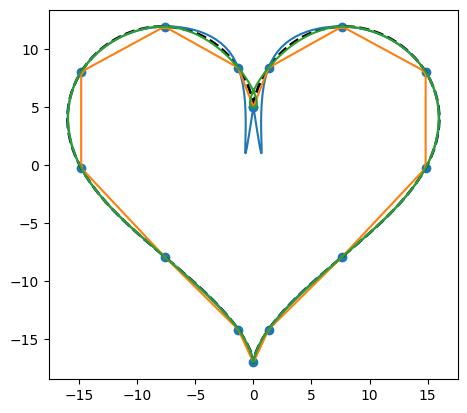

In [10]:
n = 15
interp_list = [polinomio_interpol,piecewise_linear, interp_spline3]
crea_grafici_curve(curva2,0,2*np.pi,n,interp_list)


## Applicazione

L'interpolazione di curve interviene in molti ambiti concreti. Un esempio tra tutti è costituito dai software per visualizzare e salvare disegni o scritte creati con una touch pen.

* il software rileva la posizione della penna sul supporto in tempo reale, ad intervalli di tempo prefissati $t_0,t_1,...$
* per ricreare il tratto di curva tra un istante e l'altro, si utilizzano per esempio le spline cubiche
* il calcolo di un nuovo tratto di curva spline viene calcolato in tempo reale, man mano che la penna rileva nuovi punti. Ciò è possibile perché i "pezzi" che formano la spline dipendono solo da quello precedente e dal successivo.